In [1]:
print("hello")

hello


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
sns.set_theme(style="whitegrid")

In [4]:
df = sns.load_dataset("tips")

6.Data Distribution & Skew

In [5]:
print(df["tip"].skew())
print(df["total_bill"].skew())

1.4654510370979401
1.1332130376158205


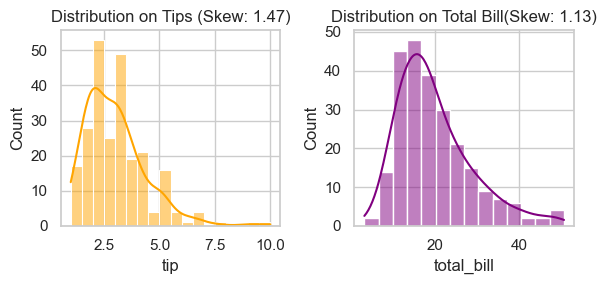

Skewness = 0: Perfectly Normal
Skewness>0: RIGHT Skewed(tail is on the right)
Skewness<0: LEFT Skewed(tail is on the left)


In [11]:
plt.figure(figsize=(6,3))
#plot 1: Tip Distribution
plt.subplot(1, 2, 1)
sns.histplot(df["tip"], kde=True, color="orange")
plt.title(f"Distribution on Tips (Skew: {df['tip'].skew():.2f})")

#plot 2:Total_bill Distribution
plt.subplot(1, 2, 2)
sns.histplot(df["total_bill"], kde=True, color="purple")
plt.title(f"Distribution on Total Bill(Skew: {df['total_bill'].skew():.2f})")
plt.tight_layout()
plt.show()
print("Skewness = 0: Perfectly Normal")
print("Skewness>0: RIGHT Skewed(tail is on the right)")
print("Skewness<0: LEFT Skewed(tail is on the left)")

Outliers Detectin

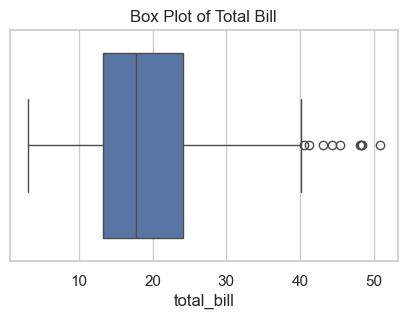

lower bound: -2.8224999999999945
upper_bound: 40.29749999999999
Number of outliers:      total_bill    tip     sex smoker   day    time  size
59        48.27   6.73    Male     No   Sat  Dinner     4
102       44.30   2.50  Female    Yes   Sat  Dinner     3
142       41.19   5.00    Male     No  Thur   Lunch     5
156       48.17   5.00    Male     No   Sun  Dinner     6
170       50.81  10.00    Male    Yes   Sat  Dinner     3
182       45.35   3.50    Male    Yes   Sun  Dinner     3
184       40.55   3.00    Male    Yes   Sun  Dinner     2
197       43.11   5.00  Female    Yes  Thur   Lunch     4
212       48.33   9.00    Male     No   Sat  Dinner     4


In [17]:
#1.Visual Method
plt.figure(figsize=(5,3))
sns.boxplot(x=df["total_bill"])
plt.title("Box Plot of Total Bill")
plt.show()

#formula method
Q1 = df["total_bill"].quantile(0.25)
Q3 = df["total_bill"].quantile(0.75)
IQR = Q3-Q1

lower_bound = Q1-1.5*IQR
upper_bound = Q3+1.5*IQR

print("lower bound:",lower_bound)
print("upper_bound:",upper_bound)

#filter outliers
outliers = df[(df["total_bill"]<lower_bound) | (df["total_bill"] > upper_bound)]
print("Number of outliers:",outliers)

Correlation Analysis

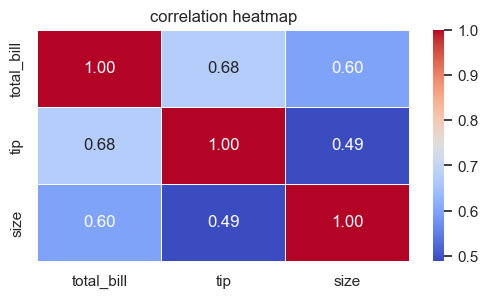


Correlation between Total bill and tip:
0.6757341092113648


In [21]:
# correlation matrix
numerical_df = df.select_dtypes(include=[np.number])
corr_matrix = numerical_df.corr()
#visualise with Heatmap
plt.figure(figsize=(6,3))
sns.heatmap(corr_matrix, annot = True, cmap="coolwarm",fmt=".2f", linewidths=0.5)
plt.title("correlation heatmap")
plt.show()
print("\nCorrelation between Total bill and tip:")
print(corr_matrix.loc['total_bill', 'tip'])